In [66]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [67]:
path_images_train = "../train2017"
path_images_val = "../val2017"
path_captions_train = "../annotations/captions_train2017.json"
path_captions_val = "../annotations/captions_val2017.json"

In [68]:
with open(path_captions_train, 'r') as file:
    train_data = json.load(file)
images_dict = {img['id'] : img['file_name'] for img in train_data['images']} # słownik (image_id : image_name)
images_ids = set(images_dict.keys())

annotation_dict = {} # słownik (image_id : [caption1, ...])
for annot in train_data['annotations']: 
    image_id = annot['image_id']
    caption = annot['caption']
    if image_id not in annotation_dict:
        annotation_dict[image_id] = []
    annotation_dict[image_id].append(caption)
annotated_images_ids = set(annotation_dict.keys())

images_names = set(os.listdir(path_images_train))

In [69]:
print(images_names == set(images_dict.values())) # czy obrazy fizycznie zgadzają się z tymi w json

True


In [70]:
print(images_ids == annotated_images_ids) # czy obrazy i podpisy się zgadzają

True


In [71]:
images_info = pd.DataFrame(train_data['images'])
images_info['aspect_ratio'] = images_info['width'] / images_info['height']

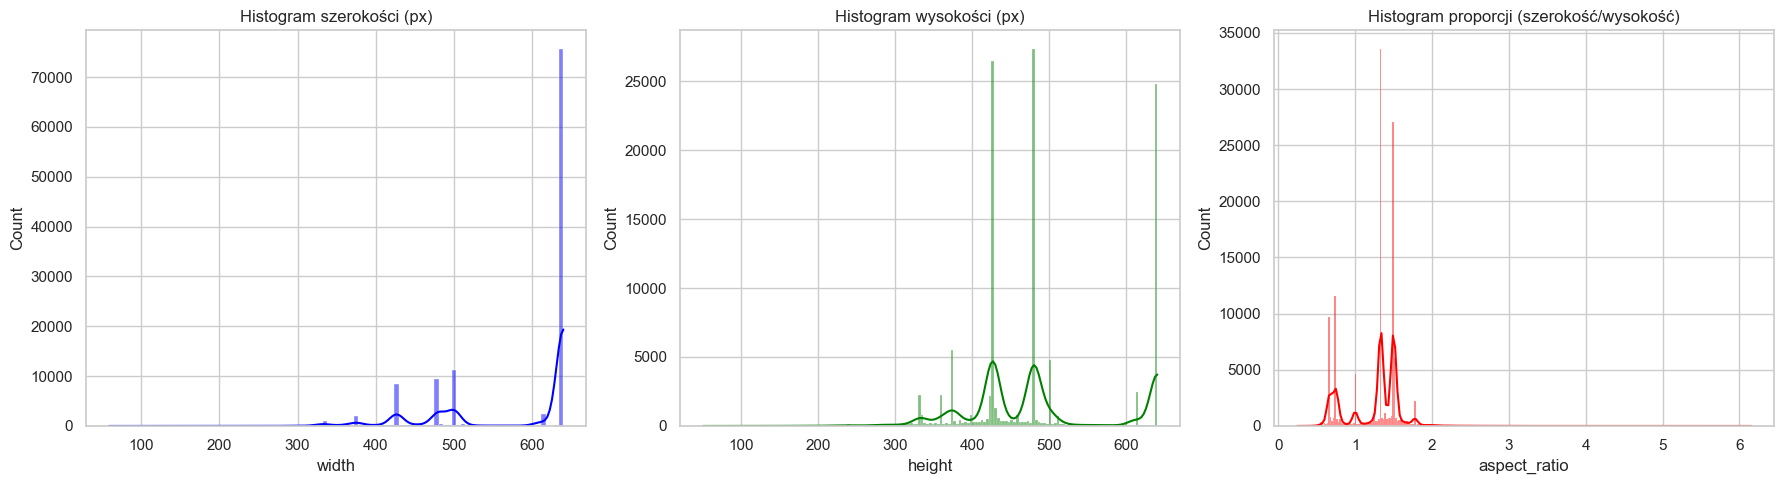

In [72]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram szerokości
sns.histplot(images_info['width'], ax=axes[0], color='blue', kde=True)
axes[0].set_title('Histogram szerokości (px)')

# 2. Histogram wysokości
sns.histplot(images_info['height'], ax=axes[1], color='green', kde=True)
axes[1].set_title('Histogram wysokości (px)')

# 3. Histogram proporcji (Aspect Ratio)
sns.histplot(images_info['aspect_ratio'], ax=axes[2], color='red', kde=True)
axes[2].set_title('Histogram proporcji (szerokość/wysokość)')

plt.tight_layout()
plt.show()

In [73]:
captions = [annot['caption'] for annot in train_data['annotations']]
word_counts_list = [len(caption.split()) for caption in captions]
word_counts = pd.DataFrame(word_counts_list, columns=['count'])

In [74]:
word_stats = {
    'Średnia' : word_counts['count'].mean(),
    'Mediana' : word_counts['count'].median(),
    'Max' : word_counts['count'].max(),
    'Min' : word_counts['count'].min()
}
word_stats_text = '\n'.join([f"{title}: {value:.2f}" for title, value in word_stats.items()])

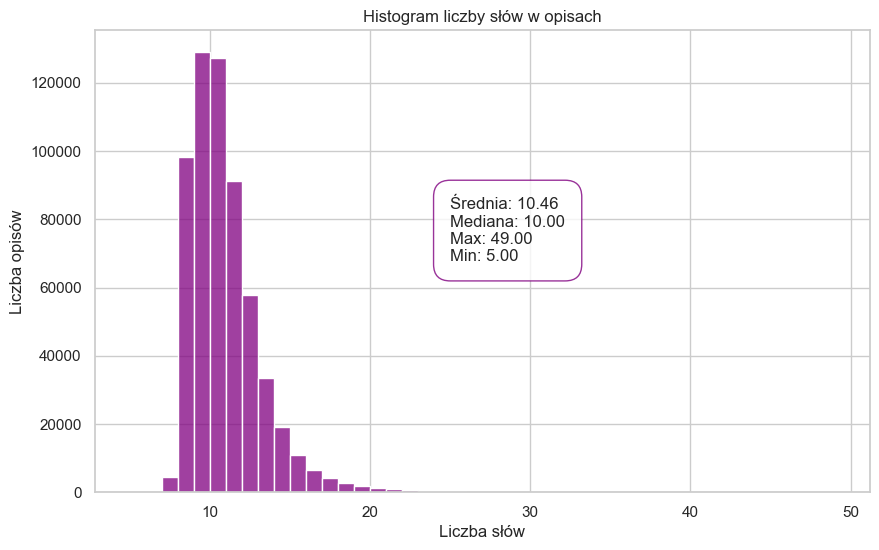

In [78]:
plt.figure(figsize=(10, 6))
sns.histplot(word_counts['count'], bins=range(min(word_counts_list), max(word_counts_list) + 1), color='purple')
plt.title('Histogram liczby słów w opisach')
plt.xlabel('Liczba słów')
plt.ylabel('Liczba opisów')
plt.text(25, plt.gca().get_ylim()[1]*0.5, word_stats_text, fontsize=12, 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='purple', boxstyle='round,pad=1'))
plt.show()

In [76]:
print(word_stats_text)

Średnia: 10.46
Mediana: 10.00
Max: 49.00
Min: 5.00


In [ ]:
captions_count = [len(x) for x in annotation_dict.values()] # ile opisów na obraz
print(Counter(captions_count))

Counter({5: 117972, 6: 312, 7: 3})
